https://www.kaggle.com/datasets/algozee/heart-decices

# **Previsão de doenças cardíacas usando aprendizado de máquina**

**Previsão da presença de doenças cardíacas usando características clínicas e de diagnóstico.**

# Sobre o conjunto de dados

**Contexto:**

As doenças cardíacas são uma das principais causas de morte em todo o mundo e continuam sendo uma grande preocupação de saúde pública. As doenças cardiovasculares geralmente se desenvolvem devido a uma combinação de fatores, como pressão alta, níveis elevados de colesterol, hábitos de vida pouco saudáveis, predisposição genética e outras condições médicas. A detecção precoce e a intervenção médica oportuna desempenham um papel crucial na redução das taxas de mortalidade e na melhoria dos resultados para os pacientes. Os procedimentos diagnósticos tradicionais dependem muito de exames clínicos, exames laboratoriais e da experiência de profissionais médicos, o que às vezes pode ser demorado e dispendioso. Com o avanço da tecnologia, o aprendizado de máquina e a análise de dados emergiram como ferramentas poderosas no setor da saúde. Essas tecnologias permitem a análise de grandes quantidades de dados de pacientes para identificar padrões e prever potenciais riscos à saúde. Este projeto baseia-se na aplicação de técnicas de aprendizado de máquina para prever a probabilidade de doenças cardíacas usando dados clínicos estruturados.

Este projeto visa desenvolver um sistema baseado em Aprendizado de Máquina para prever doenças cardíacas usando dados clínicos de pacientes. O conjunto de dados consiste em arquivos de treinamento e teste contendo atributos médicos como idade, pressão arterial, nível de colesterol, tipo de dor no peito e outros indicadores de saúde relevantes.

Os dados são inicialmente pré-processados, tratando-se os valores ausentes e codificando-se as variáveis ​​categóricas. Após a realização da análise básica dos dados, algoritmos de classificação como Regressão Logística e Árvore de Decisão são aplicados para treinar o modelo. O desempenho do modelo é avaliado utilizando métricas como acurácia e pontuação F1.

O resultado final é um modelo preditivo que pode determinar a probabilidade de doença cardíaca, auxiliando no diagnóstico precoce e na tomada de decisões médicas.

**Declaração do problema**

As doenças cardíacas continuam sendo uma das principais causas de mortalidade em todo o mundo, e a detecção precoce é essencial para o tratamento e a prevenção eficazes. No entanto, os métodos diagnósticos tradicionais podem ser demorados, caros e dependentes de extensos exames médicos. Há uma necessidade de um sistema inteligente, baseado em dados, que possa analisar os atributos clínicos do paciente e prever com precisão a probabilidade de doença cardíaca. Este projeto visa enfrentar esse desafio desenvolvendo um modelo de classificação baseado em aprendizado de máquina usando dados médicos estruturados.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df_train = pd.read_csv('train.csv')
df_test = pd.read_csv('test.csv')

# EAD

C:\Users\Usuário\AppData\Local\Temp\ipykernel_13368\1251447950.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_train, x='Heart Disease', palette='viridis')


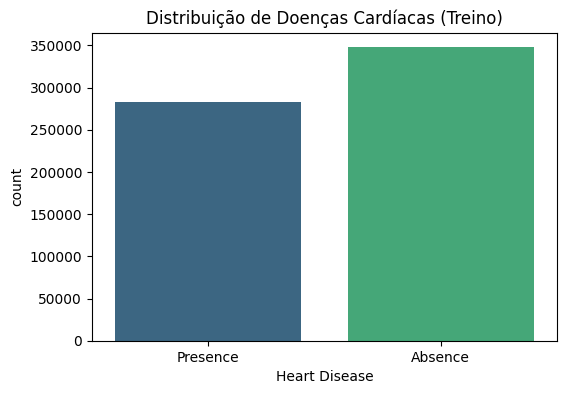

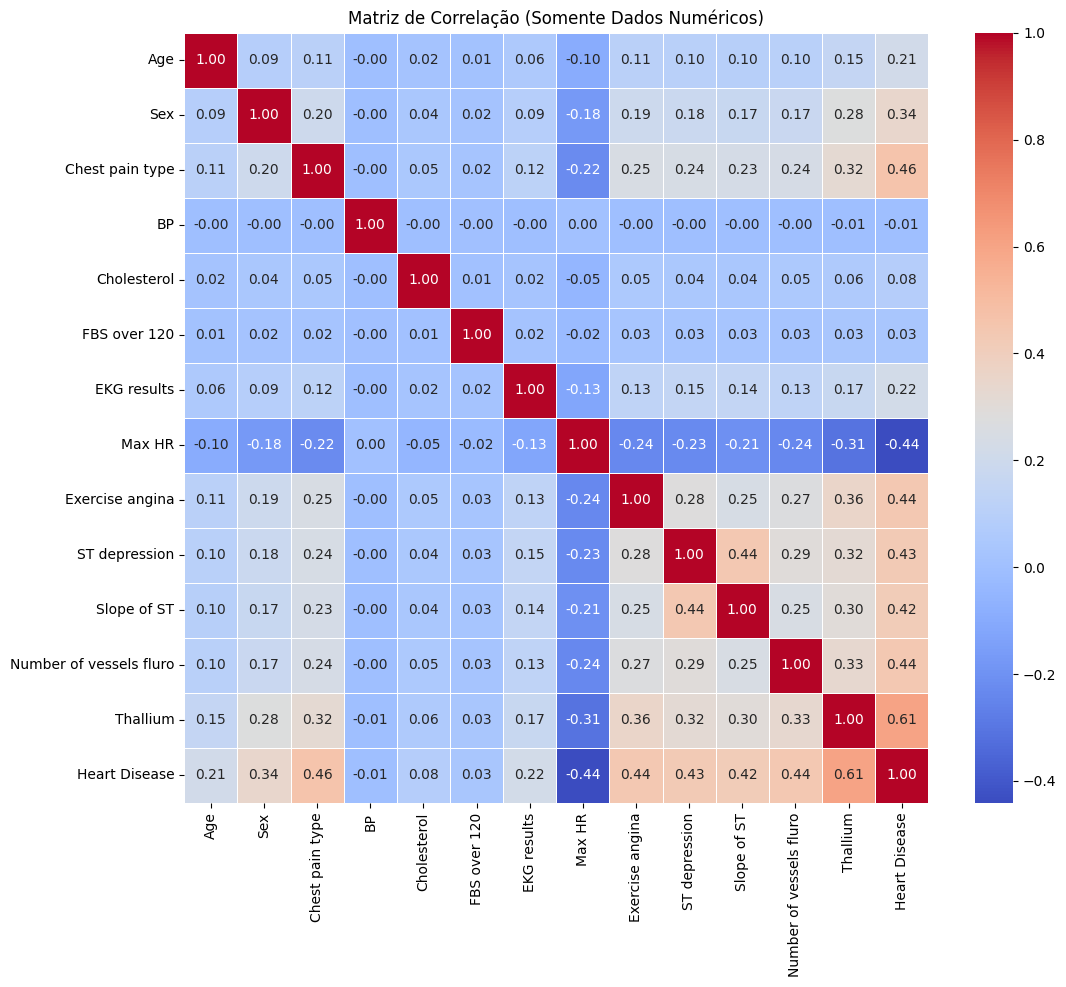

c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


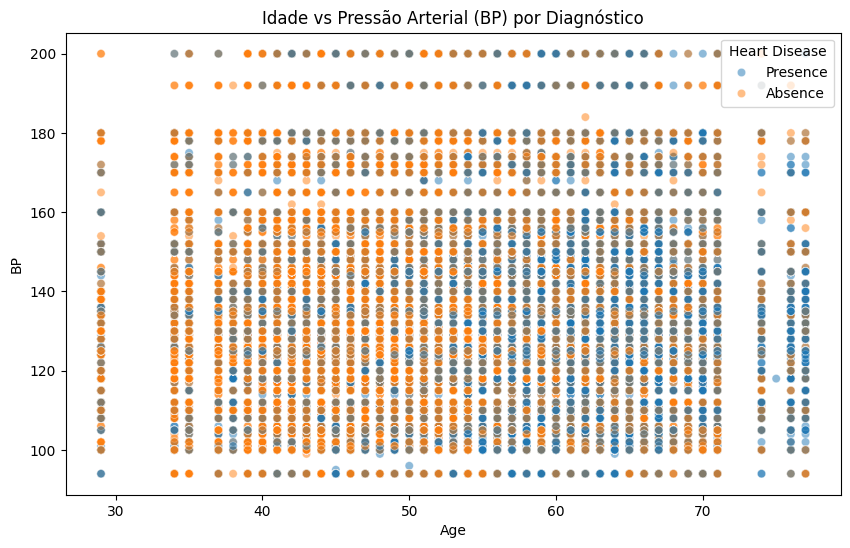

C:\Users\Usuário\AppData\Local\Temp\ipykernel_13368\1251447950.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_train, x='Heart Disease', y='Cholesterol', palette='Set2')


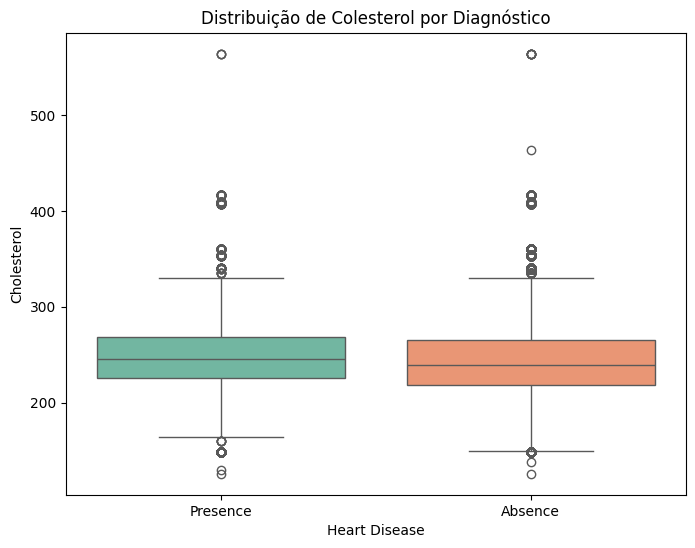

C:\Users\Usuário\AppData\Local\Temp\ipykernel_13368\1251447950.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_train, x='Heart Disease', y='Max HR', split=True, palette='magma')


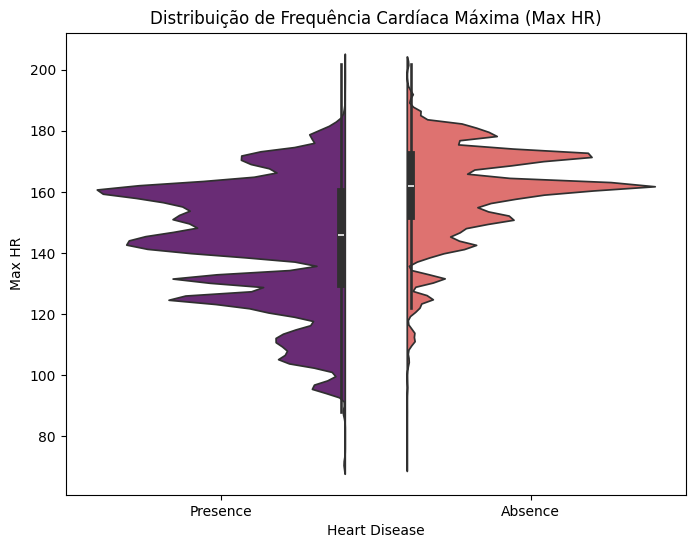

Resumo estatístico do dataset completo:
                  id            Age            Sex  Chest pain type  \
count  900000.000000  900000.000000  900000.000000    900000.000000   
mean   449999.500000      54.143656       0.715209         3.313459   
std    259807.765473       8.256054       0.451315         0.851659   
min         0.000000      29.000000       0.000000         1.000000   
25%    224999.750000      48.000000       0.000000         3.000000   
50%    449999.500000      54.000000       1.000000         4.000000   
75%    674999.250000      60.000000       1.000000         4.000000   
max    899999.000000      77.000000       1.000000         4.000000   

                  BP    Cholesterol   FBS over 120    EKG results  \
count  900000.000000  900000.000000  900000.000000  900000.000000   
mean      130.514730     245.021851       0.080007       0.980710   
std        14.985456      33.685730       0.271304       0.998754   
min        94.000000     126.000000       0.

In [2]:
#Adicionando uma flag para identificar a origem antes de juntar
df_train['Origin'] = 'Train'
df_test['Origin'] = 'Test'

#Unindo os datasets para análise de distribuição geral
df_full = pd.concat([df_train, df_test], axis=0, sort=False).reset_index(drop=True)

#Visão Geral
summary_stats = df_full.describe()

#Análise da Variável Alvo
plt.figure(figsize=(6, 4))
sns.countplot(data=df_train, x='Heart Disease', palette='viridis')
plt.title('Distribuição de Doenças Cardíacas (Treino)')
plt.show()

#Correlação entre Variáveis 
#Transformando o alvo em numérico para a correlação
df_train_numeric = df_train.copy()
df_train_numeric['Heart Disease'] = df_train_numeric['Heart Disease'].map({'Absence': 0, 'Presence': 1})

correlation_matrix = df_train_numeric.drop(columns=['id', 'Origin']).corr(numeric_only=True)

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matriz de Correlação (Somente Dados Numéricos)')
plt.show()

#Comparativo Idade e Pressão Arterial
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_train, x='Age', y='BP', hue='Heart Disease', alpha=0.5)
plt.title('Idade vs Pressão Arterial (BP) por Diagnóstico')
plt.show()

#Distribuição de Colesterol
plt.figure(figsize=(8, 6))
sns.boxplot(data=df_train, x='Heart Disease', y='Cholesterol', palette='Set2')
plt.title('Distribuição de Colesterol por Diagnóstico')
plt.show()

#Frequência Cardíaca Máxima
plt.figure(figsize=(8, 6))
sns.violinplot(data=df_train, x='Heart Disease', y='Max HR', split=True, palette='magma')
plt.title('Distribuição de Frequência Cardíaca Máxima (Max HR)')
plt.show()

print("Resumo estatístico do dataset completo:")
print(summary_stats)

| Métrica                 | Valor Médio (Dataset Total) |
| ----------------------- | --------------------------- |
| Idade Média             | 54.1 anos                   |
| Pressão Arterial (BP)   | 130.5 mmHg                  |
| Colesterol              | 245.0 mg/dl                 |
| Frequência Cardíaca Máx | 152.8 bpm                   |

# Analisar e pré-processar o conjunto de dados de doenças cardíacas para um treinamento eficaz do modelo.

# ML

In [ ]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

#Adicionando a flag 
df_train['Origin'] = 'Train'
df_test['Origin'] = 'Test'

#Mapeamento da variável alvo
df_train['Heart Disease'] = df_train['Heart Disease'].map({'Absence': 0, 'Presence': 1})

# 3. Definição das Features (X) e Alvo (y)
# CORREÇÃO: Removemos 'id', 'Heart Disease' E 'Origin'
X = df_train.drop(columns=['id', 'Heart Disease', 'Origin'])
y = df_train['Heart Disease']

# Para o teste, removemos 'id' e 'Origin'
X_test_final = df_test.drop(columns=['id', 'Origin'])

# 4. Escalonamento (Scaling)
# Agora o X contém apenas colunas numéricas (int64 e float64)
scaler = StandardScaler()

# Ajusta nos dados de treino e transforma
X_scaled = scaler.fit_transform(X)

# Transforma os dados de teste (usando a média/desvio do treino)
X_test_scaled = scaler.transform(X_test_final)

# 5. Divisão para Validação
X_train, X_val, y_train, y_val = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Sucesso! Dados prontos para o modelo.")
print(f"Colunas utilizadas: {list(X.columns)}")

ValueError: could not convert string to float: 'Train'